# Pengembangan Chatbot Interaktif untuk Simulasi Seleksi Calon Anggota Organisasi Kampus dengan Pendekatan Adaptive Questioning dan Evaluasi Jawaban Otomatis Berbasis Natural Language Processing

# 1. Import Library

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from collections import Counter

print("Semua library berhasil diimport")


Semua library berhasil diimport


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# 2. Random Seed

In [5]:
np.random.seed(42)

# 3. Load Data

In [6]:
df = pd.read_csv("recruitment_data.csv")

print("Shape Awal Dataset:", df.shape)

df.head()

Shape Awal Dataset: (1500, 11)


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


# 4. Cek Data

In [7]:
print(df.columns.tolist())

df.info()

print(df.isnull().sum())

['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy', 'HiringDecision']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   int64  
 1   Gender               1500 non-null   int64  
 2   EducationLevel       1500 non-null   int64  
 3   ExperienceYears      1500 non-null   int64  
 4   PreviousCompanies    1500 non-null   int64  
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 129.0 K

# 5. Rename Kolom

In [8]:
df = df.rename(columns={

    "Age":"Usia",
    "Gender":"JenisKelamin",
    "EducationLevel":"Semester",
    "ExperienceYears":"SkorPengalaman",
    "PreviousCompanies":"JumlahKepanitiaan",
    "DistanceFromCompany":"JarakDomisili",
    "InterviewScore":"NilaiWawancara",
    "SkillScore":"KemampuanKerjaTim",
    "PersonalityScore":"Kepribadian",
    "RecruitmentStrategy":"JalurPendaftaran",
    "HiringDecision":"StatusDiterima"

})

df.head()

,Usia,JenisKelamin,Semester,SkorPengalaman,JumlahKepanitiaan,JarakDomisili,NilaiWawancara,KemampuanKerjaTim,Kepribadian,JalurPendaftaran,StatusDiterima
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


# 6. Hapus Kolom yang tidak Relevan

In [9]:
df.drop(
    columns=[
        "JenisKelamin",
        "Usia",
        "JarakDomisili"
    ],
    inplace=True
)

print("Kolom tidak relevan berhasil dihapus")

Kolom tidak relevan berhasil dihapus


# 7. Normalisasi

In [10]:
scaler = MinMaxScaler()

df["SkorPengalaman"] = scaler.fit_transform(
    df[["SkorPengalaman"]]
) * 100

print("Normalisasi berhasil")


Normalisasi berhasil


# 8. Batasi Nilai tidak Realistis

In [11]:
df["JumlahKepanitiaan"] = df["JumlahKepanitiaan"].clip(upper=6)

df["Semester"] = df["Semester"].clip(upper=8)

print("Nilai berhasil dibatasi")

Nilai berhasil dibatasi


# 9. Feature Engineering

In [12]:
# Leadership
df["NilaiLeadership"] = (
    df["KemampuanKerjaTim"] * 0.7 +
    df["SkorPengalaman"] * 0.3
)

# Keaktifan
df["SkorKeaktifan"] = (
    df["JumlahKepanitiaan"] * 10 +
    df["SkorPengalaman"] * 0.5
)

# Softskill
df["SoftSkillScore"] = (
    df["NilaiWawancara"] +
    df["Kepribadian"]
) / 2

print("Feature engineering berhasil")


Feature engineering berhasil


# 10. Simulasi Chatbot

In [13]:
sample_answers = [

    "Saya ingin belajar leadership dan berkembang",

    "Saya siap aktif mengikuti kegiatan kampus",

    "Saya ingin menambah relasi dan pengalaman",

    "Saya tertarik berkontribusi untuk organisasi",

    "Saya siap bekerja sama dalam tim",

    "Saya ingin membantu kemajuan organisasi",

    "Saya ingin meningkatkan kemampuan komunikasi",

    "Saya tertarik belajar public speaking",

    "Saya ingin mencari pengalaman organisasi",

    "Saya ingin menjadi mahasiswa yang aktif",

    "Saya hanya ikut teman",

    "Saya kurang tertarik organisasi"

]

df["JawabanChatbot"] = np.random.choice(
    sample_answers,
    len(df)
)

print("Simulasi jawaban chatbot berhasil")


Simulasi jawaban chatbot berhasil


# 11. NLP Preprocessing

In [14]:
stop_words = set(stopwords.words("indonesian"))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

df["JawabanClean"] = df["JawabanChatbot"].apply(clean_text)

print("Preprocessing NLP berhasil")

Preprocessing NLP berhasil


# 12. NLP Feature Extraction

In [15]:
df["PanjangJawaban"] = df["JawabanClean"].apply(
    lambda x: len(x.split())
)

keywords = [

    "belajar",
    "aktif",
    "berkembang",
    "relasi",
    "kontribusi",
    "membantu",
    "tim",
    "komunikasi",
    "organisasi"

]

def keyword_score(text):

    text = str(text).lower()

    return sum(word in text for word in keywords)

df["MotivationScore"] = df["JawabanClean"].apply(
    keyword_score
)


positive_words = [

    "siap",
    "aktif",
    "ingin",
    "tertarik",
    "membantu",
    "berkembang"

]

def sentiment_score(text):

    text = str(text).lower()

    return sum(word in text for word in positive_words)

df["SentimentScore"] = df["JawabanClean"].apply(
    sentiment_score
)

print("NLP feature extraction berhasil")


NLP feature extraction berhasil


# 13. TF-IDF

In [16]:
tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    df["JawabanClean"]
)

print("TF-IDF Shape:", tfidf_matrix.shape)


TF-IDF Shape: (1500, 24)


# 14. SIMILARITY CODE

In [17]:
ideal_answers = [

    "ingin belajar berorganisasi",
    "berkomunikasi dengan baik",
    "ingin belajar dan berkembang",
    "ingin menambah pengalaman dalam kegiatan kampus",
    "berdiskusi dan pilih jalan tengah"
    "ingin menjadi mahasiswa yang lebih aktif",
    "ingin mengembangkan kemampuan diri",
    "ingin meningkatkan keterampilan sosial",
    "ingin belajar berkomunikasi dengan banyak orang",
    "ingin memperluas wawasan",
    "ingin mengenal lebih banyak teman",
    "ingin menambah jaringan pertemanan",
    "ingin membangun relasi yang bermanfaat",

    "ingin mengembangkan kemampuan kepemimpinan",
    "ingin meningkatkan kemampuan bekerja sama",
    "ingin melatih rasa tanggung jawab",
    "ingin belajar mengelola kegiatan",
    "ingin menambah pengalaman kepanitiaan",
    "ingin meningkatkan kemampuan public speaking",
    "ingin meningkatkan kemampuan presentasi",
    "ingin meningkatkan kepercayaan diri",
    "ingin belajar mengatur waktu",
    "ingin mempersiapkan diri untuk dunia kerja",

    "ingin berkontribusi bagi organisasi",
    "ingin memberikan manfaat kepada kampus",
    "ingin membantu menjalankan program organisasi",
    "ingin terlibat dalam kegiatan positif",
    "ingin memanfaatkan waktu luang dengan kegiatan bermanfaat",
    "ingin mengembangkan potensi diri",
    "ingin meningkatkan soft skill",
    "ingin menjadi pribadi yang lebih disiplin",
    "ingin menjadi mahasiswa yang produktif",
    "ingin belajar menghadapi tantangan baru",

    "ingin belajar mengambil keputusan",
    "ingin meningkatkan kemampuan problem solving",
    "ingin mendapatkan pengalaman kepemimpinan",
    "ingin belajar bekerja dalam tim",
    "ingin menjadi pribadi yang lebih mandiri",
    "ingin meningkatkan kemampuan interpersonal",
    "ingin memperoleh pengalaman yang berharga",
    "ingin aktif dalam kegiatan kemahasiswaan",
    "ingin memberikan dampak positif bagi lingkungan kampus",
    "ingin berkembang bersama organisasi"

]


medium_ideal_answers = [

    "saya selalu menghargai pendapat orang lain",
    "saya aktif berpartisipasi dalam diskusi tim",
    "saya membantu anggota tim yang membutuhkan bantuan",
    "saya menjaga komunikasi yang baik dalam kelompok",
    "saya fokus pada pencapaian tujuan bersama",

    "saya selalu menyelesaikan tugas sesuai tanggung jawab",
    "saya berusaha menyelesaikan pekerjaan tepat waktu",
    "saya terbuka terhadap kritik dan saran",
    "saya menjaga hubungan baik dengan anggota tim",
    "saya berusaha menciptakan suasana kerja yang nyaman",

    "saya mampu menyesuaikan diri dengan berbagai karakter",
    "saya mendukung keputusan yang telah disepakati bersama",
    "saya berkontribusi aktif dalam kegiatan kelompok",
    "saya membantu mencari solusi ketika tim mengalami kesulitan",
    "saya berusaha menjaga kekompakan kelompok",

    "saya membagi waktu antara kuliah dan organisasi dengan membuat jadwal",
    "saya menentukan prioritas pekerjaan berdasarkan tingkat kepentingan",
    "saya menghindari menunda pekerjaan",
    "saya mengatur waktu belajar dan organisasi secara seimbang",
    "saya disiplin terhadap jadwal yang telah dibuat",

    "saya mendengarkan pendapat yang berbeda sebelum memberikan tanggapan",
    "saya menyampaikan pendapat dengan sopan",
    "saya mengutamakan musyawarah dalam mengambil keputusan",
    "saya menghormati keputusan mayoritas",
    "saya mencari solusi terbaik untuk semua pihak",

    "saya aktif memberikan ide kepada tim",
    "saya membantu koordinasi antar anggota",
    "saya berusaha menjadi anggota tim yang dapat diandalkan",
    "saya menjaga profesionalisme dalam bekerja",
    "saya mengutamakan keberhasilan kelompok"

]

hard_ideal_answers = [

    "saya mengajak semua pihak berdiskusi untuk mencari solusi",
    "saya menyelesaikan konflik secara tenang dan objektif",
    "saya mendengarkan semua pendapat sebelum mengambil keputusan",
    "saya mencari titik temu yang dapat diterima semua pihak",
    "saya mengutamakan kepentingan organisasi dibanding kepentingan pribadi",

    "saya menghubungi anggota tim yang belum menjalankan tugasnya",
    "saya mencari tahu kendala yang dihadapi anggota tersebut",
    "saya membantu anggota tim menyelesaikan pekerjaannya",
    "saya memberikan dukungan agar anggota tetap termotivasi",
    "saya melakukan koordinasi ulang jika terjadi keterlambatan",

    "saya mengumpulkan informasi sebelum mengambil keputusan",
    "saya mempertimbangkan risiko dari setiap pilihan",
    "saya memilih solusi yang paling efektif",
    "saya berdiskusi dengan anggota tim sebelum memutuskan",
    "saya bertanggung jawab atas keputusan yang dibuat",

    "saya memberikan semangat kepada anggota tim",
    "saya mengingatkan kembali tujuan yang ingin dicapai",
    "saya melakukan evaluasi terhadap penyebab kegagalan",
    "saya menjadikan kegagalan sebagai bahan pembelajaran",
    "saya fokus mencari solusi daripada menyalahkan orang lain",

    "saya tetap menjaga komunikasi yang baik saat konflik terjadi",
    "saya berusaha menjadi penengah dalam konflik",
    "saya menyelesaikan masalah secara profesional",
    "saya menjaga kekompakan tim dalam kondisi sulit",
    "saya memastikan setiap anggota merasa didengarkan",

    "saya memberikan arahan yang jelas kepada anggota tim",
    "saya membantu tim menemukan alternatif solusi",
    "saya memotivasi anggota untuk tetap optimis",
    "saya mempertimbangkan dampak keputusan terhadap tim",
    "saya mengutamakan kerja sama untuk menyelesaikan masalah"

]

all_ideal_answers = (
    ideal_answers +
    medium_ideal_answers +
    hard_ideal_answers
)

similarity_scores = []

for answer in df["JawabanClean"].astype(str):

    scores = []

    for ideal in all_ideal_answers:

        vectors = tfidf.fit_transform([
            str(ideal),
            str(answer)
        ])

        similarity = cosine_similarity(
            vectors[0:1],
            vectors[1:2]
        )[0][0]

        scores.append(similarity)

    similarity_scores.append(
        max(scores) * 100
    )

df["SimilarityScore"] = similarity_scores

print("Similarity score berhasil dibuat")

Similarity score berhasil dibuat


# 15. NilaiChatbot

In [18]:
df["NilaiChatbot"] = (

    df["MotivationScore"] * 25 +

    df["SentimentScore"] * 20 +

    df["SimilarityScore"] * 0.4 +

    df["PanjangJawaban"] * 5

)

# Maksimal 100
df["NilaiChatbot"] = df["NilaiChatbot"].clip(
    upper=100
)

print("Nilai chatbot berhasil dibuat")


Nilai chatbot berhasil dibuat


# 16. Adaptive Questioning

In [19]:
def evaluate_answer(user_answer, level):

    cleaned = clean_text(user_answer)

    if cleaned.strip() == "":
        return 0

    if level == "Mudah":
        ideal_list = ideal_answers

    elif level == "Sedang":
        ideal_list = medium_ideal_answers

    else:
        ideal_list = hard_ideal_answers

    best_score = 0

    for ideal in ideal_list:

        ideal_words = set(
            clean_text(ideal).split()
        )

        answer_words = set(
            cleaned.split()
        )

        matching = len(
            ideal_words.intersection(
                answer_words
            )
        )

        score = (
            matching /
            len(ideal_words)
        ) * 100

        best_score = max(
            best_score,
            score
        )

    return round(best_score, 2)

In [20]:
def adaptive_level(score):

    if score >= 70:
        return "Sulit"

    elif score >= 35:
        return "Sedang"

    else:
        return "Mudah"

In [21]:
easy_questions = [

    "Apa motivasi Anda masuk organisasi?",
    "Mengapa Anda tertarik bergabung organisasi ini?",
    "Apa tujuan Anda mengikuti organisasi kampus?",
    "Apa manfaat yang ingin Anda dapatkan dari organisasi?",
    "Apa harapan Anda setelah bergabung organisasi ini?"

]

medium_questions = [

    "Bagaimana cara Anda bekerja sama dalam tim?",
    "Apa kontribusi yang ingin Anda berikan kepada organisasi?",
    "Bagaimana Anda mengatur waktu antara kuliah dan organisasi?",
    "Ceritakan pengalaman Anda bekerja dalam kelompok.",
    "Bagaimana Anda menghadapi perbedaan pendapat dalam tim?"

]

hard_questions = [

    "Bagaimana Anda menyelesaikan konflik organisasi?",
    "Apa yang akan Anda lakukan jika anggota tim tidak menjalankan tugasnya?",
    "Bagaimana Anda mengambil keputusan dalam situasi sulit?",
    "Bagaimana Anda mempertahankan motivasi tim saat menghadapi kegagalan?"

]

In [22]:
def generate_question(level):

    if level == "Mudah":
        return np.random.choice(easy_questions)

    elif level == "Sedang":
        return np.random.choice(medium_questions)

    else:
        return np.random.choice(hard_questions)

# 17. Feedback Chatbot

In [23]:
def chatbot_feedback(score):

    if score >= 80:
        return "Jawaban sangat baik dan menunjukkan motivasi tinggi"

    elif score >= 60:
        return "Jawaban cukup baik namun masih dapat dikembangkan"

    else:
        return "Jawaban kurang menunjukkan kesiapan organisasi"

df["FeedbackChatbot"] = df["NilaiChatbot"].apply(
    chatbot_feedback
)

print("Feedback chatbot berhasil dibuat")

Feedback chatbot berhasil dibuat


# 18. Final Score

In [24]:
df["FinalCandidateScore"] = (

    df["NilaiLeadership"] * 0.25 +

    df["SoftSkillScore"] * 0.25 +

    df["NilaiChatbot"] * 0.30 +

    df["Kepribadian"] * 0.20

)

print("Final score berhasil dibuat")

Final score berhasil dibuat


# 19. Rekomendasi Chatbot

In [25]:
def chatbot_decision(score):

    if score >= 75:
        return "Direkomendasikan"

    elif score >= 60:
        return "Dipertimbangkan"

    else:
        return "Tidak Direkomendasikan"

df["RekomendasiChatbot"] = df[
    "FinalCandidateScore"
].apply(chatbot_decision)

print("Rekomendasi chatbot berhasil dibuat")

Rekomendasi chatbot berhasil dibuat


# 20. Session Chatbot

In [26]:
df["SessionID"] = range(1, len(df)+1)

print("Session chatbot berhasil dibuat")

Session chatbot berhasil dibuat


# 21. Visualisasi Nilai

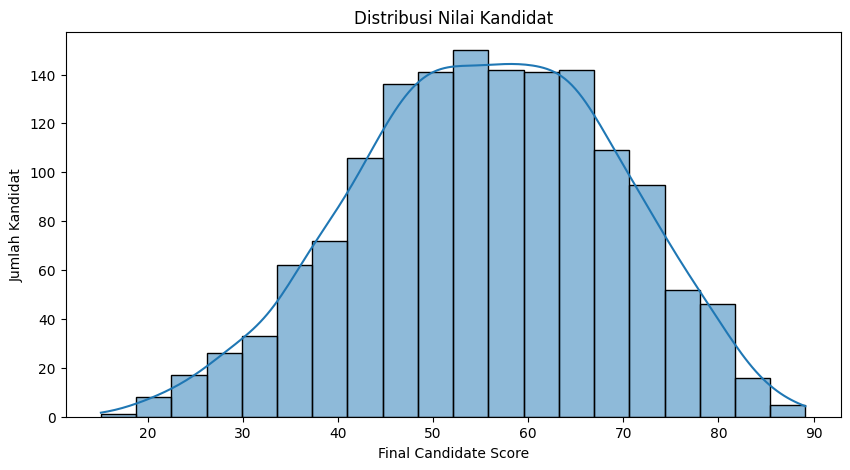

<Figure size 640x480 with 0 Axes>

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["FinalCandidateScore"],
    bins=20,
    kde=True
)

plt.title("Distribusi Nilai Kandidat")

plt.xlabel("Final Candidate Score")

plt.ylabel("Jumlah Kandidat")

plt.show()

plt.savefig("distribusi_nilai_kandidat.png", dpi=300, bbox_inches='tight')
plt.show()

# 22. Visualisasi NLP

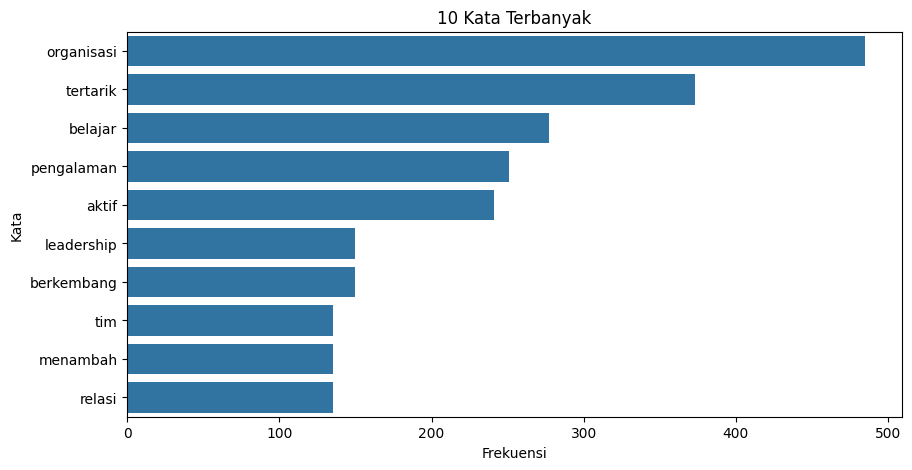

<Figure size 640x480 with 0 Axes>

In [28]:
all_words = " ".join(
    df["JawabanClean"]
).split()

word_freq = Counter(all_words)

common_words = pd.DataFrame(
    word_freq.most_common(10),
    columns=["Kata","Frekuensi"]
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=common_words,
    x="Frekuensi",
    y="Kata"
)

plt.title("10 Kata Terbanyak")

plt.show()

plt.savefig("10-kata-terbanyak.png", dpi=300, bbox_inches='tight')
plt.show()

# 23. Encoding

In [29]:
encode_cols = [

    "JawabanChatbot",
    "JawabanClean",
    "FeedbackChatbot",
    "RekomendasiChatbot"


]

for col in encode_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

print("Encoding berhasil")

Encoding berhasil


In [30]:
print(df.columns.tolist())

['Semester', 'SkorPengalaman', 'JumlahKepanitiaan', 'NilaiWawancara', 'KemampuanKerjaTim', 'Kepribadian', 'JalurPendaftaran', 'StatusDiterima', 'NilaiLeadership', 'SkorKeaktifan', 'SoftSkillScore', 'JawabanChatbot', 'JawabanClean', 'PanjangJawaban', 'MotivationScore', 'SentimentScore', 'SimilarityScore', 'NilaiChatbot', 'FeedbackChatbot', 'FinalCandidateScore', 'RekomendasiChatbot', 'SessionID']


# 24. Split Data

In [31]:
target_col = "StatusDiterima"

X = df.drop(columns=[target_col])

y = df[target_col]

print("X Shape:", X.shape)

print("y Shape:", y.shape)


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("Split data berhasil")

X Shape: (1500, 21)
y Shape: (1500,)
Split data berhasil


# 25. Scaling

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train_scaled.shape)

print("Test Shape :", X_test_scaled.shape)

Train Shape: (1200, 21)
Test Shape : (300, 21)


# 26. Deskripsi Dataset

In [33]:
print(df.describe())

          Semester  SkorPengalaman  JumlahKepanitiaan  NilaiWawancara  \
count  1500.000000     1500.000000         1500.00000     1500.000000   
mean      2.188000       51.293333            3.00200       50.564000   
std       0.862449       30.942761            1.41067       28.626215   
min       1.000000        0.000000            1.00000        0.000000   
25%       2.000000       26.666667            2.00000       25.000000   
50%       2.000000       53.333333            3.00000       52.000000   
75%       3.000000       80.000000            4.00000       75.000000   
max       4.000000      100.000000            5.00000      100.000000   

       KemampuanKerjaTim  Kepribadian  JalurPendaftaran  StatusDiterima  \
count        1500.000000  1500.000000       1500.000000     1500.000000   
mean           51.116000    49.387333          1.893333        0.310000   
std            29.353563    29.353201          0.689642        0.462647   
min             0.000000     0.000000     

# 27. Cek Data Final

In [34]:
df.head(20)

,Semester,SkorPengalaman,JumlahKepanitiaan,NilaiWawancara,KemampuanKerjaTim,Kepribadian,JalurPendaftaran,StatusDiterima,NilaiLeadership,SkorKeaktifan,...,JawabanClean,PanjangJawaban,MotivationScore,SentimentScore,SimilarityScore,NilaiChatbot,FeedbackChatbot,FinalCandidateScore,RekomendasiChatbot,SessionID
0,2,0.000000,3,48,78,91,1,1,54.6,30.000000,...,6,3,1,0,41.120706,56.448282,1,66.159485,0,1
1,4,80.000000,3,35,68,80,2,1,71.6,70.000000,...,9,3,2,1,41.120706,100.000000,2,78.275000,1,2
2,2,20.000000,2,20,67,13,2,0,52.9,30.000000,...,7,1,0,0,33.517574,18.407030,1,25.472109,2,3
3,2,33.333333,2,36,27,70,3,0,28.9,36.666667,...,8,4,1,1,29.121942,76.648777,0,57.469633,2,4
4,1,40.000000,1,23,52,85,2,0,48.4,30.000000,...,11,1,1,0,33.517574,43.407030,1,55.622109,2,5
5,3,93.333333,4,54,50,50,1,1,63.0,86.666667,...,6,3,1,0,41.120706,56.448282,1,55.684485,2,6
6,2,40.000000,1,24,52,64,3,0,48.4,30.000000,...,2,2,1,1,33.517574,68.407030,0,56.422109,2,7
7,4,86.666667,3,6,3,92,3,0,28.1,73.333333,...,4,3,1,0,41.120706,56.448282,1,54.609485,2,8
8,3,40.000000,5,80,78,51,1,1,66.6,70.000000,...,6,3,1,0,41.120706,56.448282,1,60.159485,0,9
9,2,13.333333,5,92,16,94,3,0,15.2,56.666667,...,7,1,0,0,33.517574,18.407030,1,51.372109,2,10


# 28. Training & Evaluasi Model

In [35]:
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# 29. Naive Bayes

In [36]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("====================================")
print("HASIL MODEL NAIVE BAYES")
print("====================================")

print("Accuracy:",
      accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_nb
))

print("\nConfusion Matrix:\n")

print(confusion_matrix(
    y_test,
    y_pred_nb
))

HASIL MODEL NAIVE BAYES
Accuracy: 0.8

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       207
           1       0.68      0.67      0.67        93

    accuracy                           0.80       300
   macro avg       0.77      0.76      0.76       300
weighted avg       0.80      0.80      0.80       300


Confusion Matrix:

[[178  29]
 [ 31  62]]


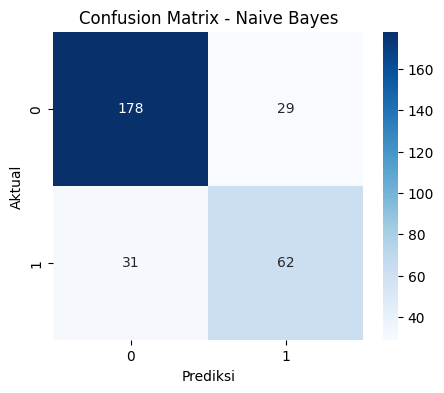

<Figure size 640x480 with 0 Axes>

In [37]:
# visualisasi confusion matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_nb),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Naive Bayes")

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.show()
plt.savefig("confusion_matrix_naivebayes.png", dpi=300, bbox_inches='tight')
plt.show()

# 30. RandomForest

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("====================================")
print("HASIL MODEL RANDOM FOREST")
print("====================================")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_rf
))

print("\nConfusion Matrix:\n")

print(confusion_matrix(
    y_test,
    y_pred_rf
))

HASIL MODEL RANDOM FOREST
Accuracy: 0.92

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       207
           1       0.95      0.78      0.86        93

    accuracy                           0.92       300
   macro avg       0.93      0.88      0.90       300
weighted avg       0.92      0.92      0.92       300


Confusion Matrix:

[[203   4]
 [ 20  73]]


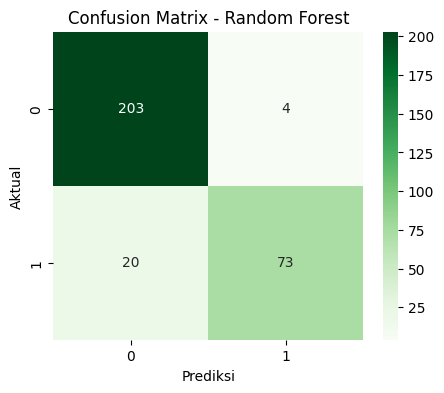

<Figure size 640x480 with 0 Axes>

In [39]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.show()
plt.savefig("confusion_matrix_randomforest.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
used_questions = []

def get_unique_question(question_list):

    available = [
        q for q in question_list
        if q not in used_questions
    ]

    if len(available) == 0:
        available = question_list

    question = np.random.choice(available)

    used_questions.append(question)

    return question


print("="*60)
print("CHATBOT INTERAKTIF SELEKSI ORGANISASI")
print("="*60)

level = "Mudah"

question = get_unique_question(
    easy_questions
)

total_score = 0

for i in range(5):

    print("\nBOT :", question)

    answer = input("ANDA : ")

    score = evaluate_answer(
        answer,
        level
    )

    total_score += score

    level = adaptive_level(score)

    print("Skor :", round(score,2))
    print("Level :", level)

    if level == "Mudah":

        question = get_unique_question(
            easy_questions
        )

    elif level == "Sedang":

        question = get_unique_question(
            medium_questions
        )

    else:

        question = get_unique_question(
            hard_questions
        )

final_score = total_score / 5

print("\n===== HASIL AKHIR =====")

print(
    "Nilai Akhir :",
    round(final_score,2)
)

print(
    "Rekomendasi :",
    chatbot_decision(
        final_score
    )
)

CHATBOT INTERAKTIF SELEKSI ORGANISASI

BOT : Apa tujuan Anda mengikuti organisasi kampus?
